## Importing the libraries

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import json

## Importing the dataset

In [2]:
df = pd.read_csv("../../dataSet/marketing_and_sales_clean.csv")

## Splitting the dataset into the Training set and Test set

In [3]:
X = df[["TV", "Radio", "Influencer", "Social Media"]].values
y = df["Sales"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

On entraine le model sur 2/3 des données, le 3e servira au test

## Training

In [4]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print('Meilleurs paramètres:', grid_search.best_params_)
lm = grid_search.best_estimator_

c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Meilleurs paramètres: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}


Ici param_grid contient une liste de possibilité pour chacune des 4 variables à haute importance de notre modèle. <br/>
Ce dictionnaire servira à "GridSearchCV" qui fera des combinaisons en se basant sur les différents paramètres et nous renverra le paramètrage du model le plus efficient. <br/>
En l'occurence :
- 'max_depth': 30, 
- 'max_features': 'sqrt', 
- 'min_samples_split': 2, 
- 'n_estimators': 200

In [5]:
print('Coefficients: \n', lm.feature_importances_)

Coefficients: 
 [0.6829347  0.27264379 0.00093014 0.04349138]


On observe les coefficients suivants : 
- TV : 0.6829347
- Radio : 0.27264379
- Influencer : 0.00093014
- Social Media : 0.04349138<br/>
<br/>
La variable TV étant prédominante, tout en sachant que cette dernière à une correlation de 1 avec la cible, on peut déduire qu'il y a une pondération déséquilibré ce qui dessert notre model.

## Prédiction

Text(0, 0.5, 'Predicted Y')

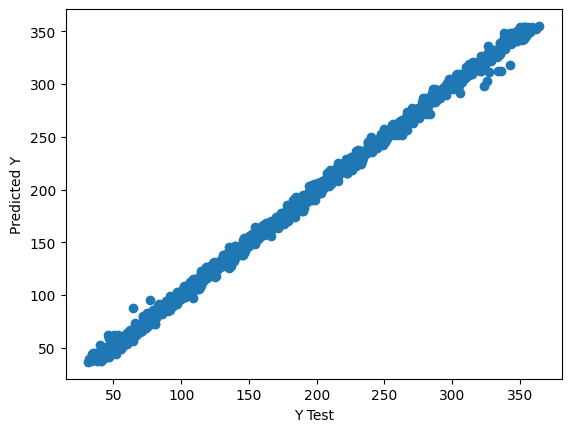

In [6]:
predictions = lm.predict(X_test)
plt.scatter(y_test, predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

## Regression Evaluation Metrics

In [ ]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RMSE = metrics.root_mean_squared_error(y_test, predictions)
R2 = metrics.r2_score(y_test, predictions)
print(f"MAE : {MAE}\nMSE : {MSE}\nRMSE : {RMSE}\nR2 : {R2}\n")
with open('../saved_models/random_forest_regressor/metrics.json', 'w') as f:
    f.write(json.dump({MAE, MSE, RMSE, R2}))

MAE : 3.0389379001968435
MSE : 16.606935797240833
RMSE : 4.075160830843469
R2 : 0.9981111440890378



## Export model

In [8]:
import pickle

with open('../saved_models/random_forest_regressor/model.pkl', 'wb') as f:
    pickle.dump(lm, f)